# Vector RAG vs Graph RAG: Real Holdings Benchmark

**Chapter 23: Knowledge Graphs for Financial AI**

**Docker image**: `ml4t-gpu`

This notebook benchmarks graph retrieval against embedding-based retrieval on
the real 13F holdings corpus used throughout Chapter 23.

**Learning Objectives**:
- Build a benchmark from real institutional holdings rather than synthetic prompts
- Compare graph retrieval and vector retrieval on direct lookup and multi-entity questions
- Measure support recall and retrieval-token budgets on the same corpus

**Book Reference**: Chapter 23, Section 23.3 (Graph RAG: Deterministic Relational Reasoning)

**Prerequisites**: The 13F artifacts written by
`data/equities/positioning/13f_download.py` (run that first if missing).
This notebook requires `sentence-transformers` for the vector baseline
and does not simulate outcomes.

In [1]:
"""Compare structured and embedding retrieval on real 13F holdings."""

from __future__ import annotations

import hashlib
import json
import logging
import warnings
from dataclasses import dataclass
from enum import Enum
from math import ceil

warnings.filterwarnings(
    "ignore",
    category=SyntaxWarning,
    message=r"'return' in a 'finally' block",
)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from sentence_transformers import SentenceTransformer

from data import load_institutional_holdings_13f
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

In [2]:
MAX_STOCKS = 250
TOP_K_VECTOR = 10
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
BENCHMARK_CUTOFF = "2026-02-17"

## 1. Load Real Holdings Data

In [3]:
holdings_df = load_institutional_holdings_13f()
required_columns = {
    "cik",
    "company_name",
    "issuer",
    "cusip",
    "filing_date",
    "value_thousands",
    "shares",
}
assert required_columns <= set(holdings_df.columns)
assert holdings_df.filter(pl.any_horizontal(pl.col(list(required_columns)).is_null())).is_empty()
print(f"Loaded {len(holdings_df)} raw holdings rows from the 13F loader")
holdings_df = holdings_df.with_columns(
    pl.col(["company_name", "issuer"]).str.replace_all(r"\s+", " ").str.strip_chars()
)

Loaded 209316 raw holdings rows from the 13F loader


### Point-in-Time Position Snapshot

Collapse all eligible filings to the latest disclosed row for each
institution-security pair at the fixed benchmark cutoff.

The source retains the legacy field name `value_thousands`, but post-2022 SEC
filings report these position values in dollars. Document text therefore
preserves the value at scale factor 1 and labels it in dollars.

In [4]:
documents_df = (
    holdings_df.filter(pl.col("filing_date") <= pl.lit(BENCHMARK_CUTOFF).str.to_date())
    .group_by("cik", "company_name", "issuer", "cusip", "filing_date")
    .agg(
        pl.sum("value_thousands").alias("value_thousands"),
        pl.sum("shares").alias("shares"),
    )
    .sort("filing_date", descending=True)
    .unique(subset=["cik", "cusip"], keep="first", maintain_order=True)
    .with_columns(
        pl.concat_str(["cik", "cusip", "filing_date"], separator="|").alias("doc_id"),
        pl.format(
            "Institution {} reported holding {} shares of {} (CUSIP {}) "
            "with a reported value of ${} on {}.",
            pl.col("company_name"),
            pl.col("shares"),
            pl.col("issuer"),
            pl.col("cusip"),
            pl.col("value_thousands"),
            pl.col("filing_date"),
        ).alias("document_text"),
    )
)
assert documents_df.select(pl.struct(["cik", "cusip"]).is_duplicated().sum()).item() == 0
assert documents_df["filing_date"].max().isoformat() <= BENCHMARK_CUTOFF
snapshot_row_count = len(documents_df)

### Benchmark Universe

Rank stocks only after collapsing the corpus to one position per institution-stock pair.

In [5]:
top_stocks = (
    documents_df.group_by("issuer")
    .agg(pl.sum("value_thousands").alias("total_value"))
    .sort("total_value", descending=True)
    .head(MAX_STOCKS)
)
documents_df = documents_df.filter(pl.col("issuer").is_in(top_stocks["issuer"].implode()))

top_institutions = (
    documents_df.group_by("company_name")
    .agg(pl.sum("value_thousands").alias("total_value"))
    .sort("total_value", descending=True)
)

print(f"Benchmark cutoff: {BENCHMARK_CUTOFF}")
print(f"Benchmark corpus rows: {len(documents_df)} latest institution-stock positions")
print(f"Institutions: {documents_df['company_name'].n_unique()}")
print(f"Stocks: {documents_df['issuer'].n_unique()}")

Benchmark cutoff: 2026-02-17
Benchmark corpus rows: 3778 latest institution-stock positions
Institutions: 10
Stocks: 250


## 2. Benchmark Question Set

In [6]:
class QueryKind(Enum):
    """Types of benchmark questions for RAG comparison."""

    HOLDERS = "holders"
    CO_OWNERS = "co_owners"
    HOLDINGS = "holdings"

### Benchmark Question Contract

In [7]:
@dataclass
class BenchmarkQuestion:
    """A single benchmark question with expected support documents."""

    text: str
    kind: QueryKind
    issuer: str | None = None
    issuer_2: str | None = None
    institution: str | None = None
    support_doc_ids: tuple[str, ...] = ()

### Question Generators

Build benchmark questions from the real holdings data, recording the expected
support document IDs for recall measurement.

In [8]:
def make_holders_question(issuer: str) -> BenchmarkQuestion:
    """Build a 'who holds this stock?' question with expected support rows."""
    support = (
        documents_df.filter(pl.col("issuer") == issuer)
        .sort("value_thousands", descending=True)
        .head(5)["doc_id"]
        .to_list()
    )
    return BenchmarkQuestion(
        text=f"Which institutions held {issuer}?",
        kind=QueryKind.HOLDERS,
        issuer=issuer,
        support_doc_ids=tuple(support),
    )

#### Institution-Holdings Questions

In [9]:
def make_holdings_question(institution: str) -> BenchmarkQuestion:
    """Build a 'what does this institution hold?' question with expected support rows."""
    support = (
        documents_df.filter(pl.col("company_name") == institution)
        .sort("value_thousands", descending=True)
        .head(5)["doc_id"]
        .to_list()
    )
    return BenchmarkQuestion(
        text=f"What were {institution}'s largest holdings?",
        kind=QueryKind.HOLDINGS,
        institution=institution,
        support_doc_ids=tuple(support),
    )

#### Co-Ownership Questions

In [10]:
def make_coowners_question(issuer_1: str, issuer_2: str) -> BenchmarkQuestion:
    """Build a 'who holds both stocks?' question with expected support rows."""
    holders_1 = set(
        documents_df.filter(pl.col("issuer") == issuer_1)["company_name"].unique().to_list()
    )
    holders_2 = set(
        documents_df.filter(pl.col("issuer") == issuer_2)["company_name"].unique().to_list()
    )
    shared_institutions = sorted(holders_1 & holders_2)

    support_rows = documents_df.filter(
        pl.col("company_name").is_in(shared_institutions)
        & pl.col("issuer").is_in([issuer_1, issuer_2])
    ).sort(["company_name", "value_thousands"], descending=[False, True])
    support = support_rows["doc_id"].head(6).to_list()

    return BenchmarkQuestion(
        text=f"Which institutions held both {issuer_1} and {issuer_2}?",
        kind=QueryKind.CO_OWNERS,
        issuer=issuer_1,
        issuer_2=issuer_2,
        support_doc_ids=tuple(support),
    )

In [11]:
top_issuers = top_stocks["issuer"].head(4).to_list()
benchmark_questions = [
    make_holders_question(top_issuers[0]),
    make_holders_question(top_issuers[1]),
    make_coowners_question(top_issuers[0], top_issuers[1]),
    make_coowners_question(top_issuers[0], top_issuers[2]),
]
benchmark_questions.extend(
    make_holdings_question(institution)
    for institution in top_institutions["company_name"].head(3).to_list()
)

print(f"Benchmark questions: {len(benchmark_questions)}")
for question in benchmark_questions:
    print("-", question.text)

Benchmark questions: 7
- Which institutions held APPLE INC?
- Which institutions held ISHARES TR?
- Which institutions held both APPLE INC and ISHARES TR?
- Which institutions held both APPLE INC and AMERICAN EXPRESS CO?
- What were CITADEL ADVISORS LLC's largest holdings?
- What were BERKSHIRE HATHAWAY INC's largest holdings?
- What were MILLENNIUM MANAGEMENT LLC's largest holdings?


## 3. Graph Retrieval

Graph retrieval here is a deterministic, oracle-style structured lookup: it
resolves each question with the same relational predicates that define the gold
support set, so it returns exact rows by construction. It is the structured-
database baseline, not a model competing with vector search under semantic
ambiguity. The comparison isolates what an explicit relational representation
buys over embedding similarity, not which model is "smarter".

In [12]:
def graph_retrieve(question: BenchmarkQuestion) -> list[str]:
    """Return exact support rows using structured holdings filters."""
    if question.kind == QueryKind.HOLDERS:
        rows = (
            documents_df.filter(pl.col("issuer") == question.issuer)
            .sort("value_thousands", descending=True)
            .head(5)
        )
        return rows["doc_id"].to_list()

    if question.kind == QueryKind.HOLDINGS:
        rows = (
            documents_df.filter(pl.col("company_name") == question.institution)
            .sort("value_thousands", descending=True)
            .head(5)
        )
        return rows["doc_id"].to_list()

    holders_1 = set(
        documents_df.filter(pl.col("issuer") == question.issuer)["company_name"].unique().to_list()
    )
    holders_2 = set(
        documents_df.filter(pl.col("issuer") == question.issuer_2)["company_name"]
        .unique()
        .to_list()
    )
    shared = sorted(holders_1 & holders_2)
    rows = documents_df.filter(
        pl.col("company_name").is_in(shared)
        & pl.col("issuer").is_in([question.issuer, question.issuer_2])
    ).sort(["company_name", "value_thousands"], descending=[False, True])
    return rows["doc_id"].head(6).to_list()

### Graph Token Budget

Estimate the token cost of a structured-row response by concatenating the
selected fields with separators and applying the same rough words-per-token
multiplier the vector side uses, so the two budgets differ by representation
rather than by how they were counted. Neither is a tokenizer count.

In [13]:
def graph_token_budget(doc_ids: list[str]) -> int:
    """Estimate the token budget for structured graph rows."""
    if not doc_ids:
        return 0
    rows = documents_df.filter(pl.col("doc_id").is_in(doc_ids)).select(
        pl.concat_str(
            ["company_name", "issuer", "value_thousands", "filing_date"],
            separator=" | ",
        ).alias("row_text")
    )
    return sum(ceil(len(text.split()) * 1.3) for text in rows["row_text"].to_list())

## 4. Vector Retrieval

In [14]:
assert torch.cuda.is_available(), "Production embedding inference requires CUDA"
encoder = SentenceTransformer(EMBEDDING_MODEL, device="cuda")
assert encoder.device.type == "cuda"
print(f"Embedding device: {encoder.device} ({torch.cuda.get_device_name(0)})")
document_texts = documents_df["document_text"].to_list()
document_ids = documents_df["doc_id"].to_list()
document_embeddings = encoder.encode(
    document_texts,
    normalize_embeddings=True,
    show_progress_bar=False,
)

Embedding device: cuda:0 (NVIDIA GeForce RTX 3090)


### Embedding-Similarity Retrieval

In [15]:
def vector_retrieve(question: BenchmarkQuestion, top_k: int = TOP_K_VECTOR) -> list[str]:
    """Retrieve the closest holdings rows by embedding similarity."""
    query_embedding = encoder.encode([question.text], normalize_embeddings=True)[0]
    scores = document_embeddings @ query_embedding
    top_indices = np.argsort(scores)[-top_k:][::-1]
    return [document_ids[idx] for idx in top_indices]

### Vector Token Budget

The vector payload uses the retrieved prose statements, whereas the graph
payload uses compact structured fields. Both estimates use the same rough
words-to-token multiplier. The difference therefore includes representation
format and is not a tokenizer-measured inference-cost comparison.

In [16]:
def vector_token_budget(doc_ids: list[str]) -> int:
    """Estimate token budget from retrieved free-text holdings rows."""
    if not doc_ids:
        return 0
    texts = documents_df.filter(pl.col("doc_id").is_in(doc_ids))["document_text"].to_list()
    return sum(ceil(len(text.split()) * 1.3) for text in texts)

## 5. Run Benchmark

In [17]:
rows: list[dict[str, object]] = []
for question in benchmark_questions:
    gold = set(question.support_doc_ids)
    assert gold, f"Question has no support rows: {question.text}"

    graph_doc_ids = graph_retrieve(question)
    vector_doc_ids = vector_retrieve(question)

    graph_recall = len(gold & set(graph_doc_ids)) / len(gold) if gold else 0.0
    vector_recall = len(gold & set(vector_doc_ids)) / len(gold) if gold else 0.0

    rows.append(
        {
            "question": question.text,
            "kind": question.kind.value,
            "system": "graph",
            "support_recall": graph_recall,
            "retrieved_docs": len(graph_doc_ids),
            "retrieval_tokens": graph_token_budget(graph_doc_ids),
        }
    )
    rows.append(
        {
            "question": question.text,
            "kind": question.kind.value,
            "system": "vector",
            "support_recall": vector_recall,
            "retrieved_docs": len(vector_doc_ids),
            "retrieval_tokens": vector_token_budget(vector_doc_ids),
        }
    )

results = pl.DataFrame(rows)
assert results.filter(pl.col("system") == "graph")["support_recall"].min() == 1.0

In [18]:
summary = (
    results.group_by("system")
    .agg(
        pl.mean("support_recall").alias("avg_support_recall"),
        pl.mean("retrieval_tokens").alias("avg_retrieval_tokens"),
        pl.mean("retrieved_docs").alias("avg_retrieved_docs"),
    )
    .sort("system")
)

by_kind = (
    results.group_by(["system", "kind"])
    .agg(
        pl.mean("support_recall").alias("avg_support_recall"),
        pl.mean("retrieval_tokens").alias("avg_retrieval_tokens"),
    )
    .sort(["kind", "system"])
)

print("Per-question retrieval audit:")
results.select(
    "question",
    "kind",
    "system",
    "support_recall",
    "retrieved_docs",
    "retrieval_tokens",
)

Per-question retrieval audit:


question,kind,system,support_recall,retrieved_docs,retrieval_tokens
str,str,str,f64,i64,i64
"""Which institutions held APPLE …","""holders""","""graph""",1.0,5,71
"""Which institutions held APPLE …","""holders""","""vector""",1.0,10,289
"""Which institutions held ISHARE…","""holders""","""graph""",1.0,5,65
"""Which institutions held ISHARE…","""holders""","""vector""",0.0,10,280
"""Which institutions held both A…","""co_owners""","""graph""",1.0,6,90
…,…,…,…,…,…
"""What were CITADEL ADVISORS LLC…","""holdings""","""vector""",0.0,10,292
"""What were BERKSHIRE HATHAWAY I…","""holdings""","""graph""",1.0,5,73
"""What were BERKSHIRE HATHAWAY I…","""holdings""","""vector""",0.4,10,294


Support recall measures whether each method retrieves the rows used to define
an answer as of the benchmark cutoff. The structured lookup is an oracle built
from those same predicates, so its perfect recall is a construction property,
not an estimated model advantage.

## 6. Headline metrics, and how to read them

One of these two numbers is a measurement and the other is an assertion. The
oracle's recall is 1 because its predicates are the ones that built the gold
set, so the "delta" between the systems is just one minus the vector arm's
recall wearing a comparative label. The vector figure is the only estimated
quantity here.

The token figures compare a structured row against the prose sentence built
from the same fields, so the difference is a property of the two
representations rather than of the retrievers. It is worth knowing - a
relational answer is compact - and it is not a model efficiency result.

In [19]:
graph_summary = summary.filter(pl.col("system") == "graph").row(0, named=True)
vector_summary = summary.filter(pl.col("system") == "vector").row(0, named=True)

recall_delta = graph_summary["avg_support_recall"] - vector_summary["avg_support_recall"]
token_reduction = 1.0 - (
    graph_summary["avg_retrieval_tokens"] / vector_summary["avg_retrieval_tokens"]
)

print("\nReal-data comparison")
print(
    f"Relational oracle support recall: {graph_summary['avg_support_recall']:.2%} (by construction)"
)
print(f"Vector support recall:            {vector_summary['avg_support_recall']:.2%}")
print(f"  the difference, {recall_delta:.2%}, is one minus the vector figure and nothing more")
print(
    f"Retrieval tokens: {graph_summary['avg_retrieval_tokens']:.0f} for structured rows against "
    f"{vector_summary['avg_retrieval_tokens']:.0f} for the prose form of the same rows "
    f"({token_reduction:.0%} fewer)"
)


Real-data comparison
Relational oracle support recall: 100.00% (by construction)
Vector support recall:            31.90%
  the difference, 68.10%, is one minus the vector figure and nothing more
Retrieval tokens: 75 for structured rows against 288 for the prose form of the same rows (74% fewer)


### Retrieval Comparison by Query Type

Compare both support recall and estimated context by question type. The
structured arm is an oracle baseline because its predicates define the gold
support rows.

In [20]:
query_kinds = ["holders", "co_owners", "holdings"]
kind_labels = ["Holder", "Co-owner", "Holdings"]
x = np.arange(len(query_kinds))
width = 0.36
graph_recalls = [
    by_kind.filter((pl.col("system") == "graph") & (pl.col("kind") == kind))[
        "avg_support_recall"
    ].item()
    for kind in query_kinds
]
vector_recalls = [
    by_kind.filter((pl.col("system") == "vector") & (pl.col("kind") == kind))[
        "avg_support_recall"
    ].item()
    for kind in query_kinds
]
graph_tokens = [
    by_kind.filter((pl.col("system") == "graph") & (pl.col("kind") == kind))[
        "avg_retrieval_tokens"
    ].item()
    for kind in query_kinds
]
vector_tokens = [
    by_kind.filter((pl.col("system") == "vector") & (pl.col("kind") == kind))[
        "avg_retrieval_tokens"
    ].item()
    for kind in query_kinds
]

#### Render Support and Context Panels

The oracle's recall is drawn as a reference line rather than as a series. It
is flat at 1 for every question kind and cannot be otherwise, so a bar for it
would put an assertion beside a measurement and invite the reader to compare
their heights.

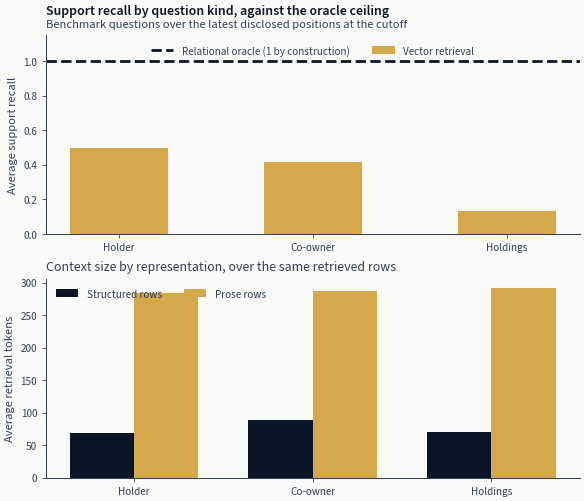

In [21]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], constrained_layout=True)
axes[0].bar(x, vector_recalls, width * 1.4, label="Vector retrieval", color=COLORS["amber"])
axes[0].axhline(
    graph_summary["avg_support_recall"],
    color=COLORS["blue"],
    linestyle="--",
    linewidth=2,
    label="Relational oracle (1 by construction)",
)
axes[0].set_xticks(x, kind_labels)
axes[0].set_ylabel("Average support recall")
axes[0].set_ylim(0, 1.15)
axes[0].legend(frameon=False, ncol=2, loc="upper center")

axes[1].bar(x - width / 2, graph_tokens, width, color=COLORS["blue"], label="Structured rows")
axes[1].bar(x + width / 2, vector_tokens, width, color=COLORS["amber"], label="Prose rows")
axes[1].set_xticks(x, kind_labels)
axes[1].set_ylabel("Average retrieval tokens")
axes[1].set_title("Context size by representation, over the same retrieved rows", loc="left")
axes[1].legend(frameon=False, ncol=2)

add_message_title(
    axes[0],
    "Support recall by question kind, against the oracle ceiling",
    subtitle="Benchmark questions over the latest disclosed positions at the cutoff",
)
show_with_alt(
    fig,
    "Two stacked panels sharing three question-kind categories on the horizontal axis. Top: "
    "bars for vector retrieval's average support recall, well below a dashed horizontal "
    "reference line at one marking the relational oracle; the bars differ across the three "
    "kinds and none reaches the line. Bottom: paired bars of average retrieval tokens, the "
    "structured-row bar much shorter than the prose-row bar in every category.",
)

### Machine-Readable Completion Record

In [22]:
completion_record = {
    "embedding_device": str(encoder.device),
    "embedding_model": EMBEDDING_MODEL,
    "embedding_shape": list(document_embeddings.shape),
    "embedding_sha256": hashlib.sha256(document_embeddings.tobytes()).hexdigest(),
    "raw_rows": len(holdings_df),
    "snapshot_rows": snapshot_row_count,
    "corpus_rows": len(documents_df),
    "institutions": documents_df["company_name"].n_unique(),
    "stocks": documents_df["issuer"].n_unique(),
    "questions": len(benchmark_questions),
    "graph_support_recall": round(graph_summary["avg_support_recall"], 6),
    "vector_support_recall": round(vector_summary["avg_support_recall"], 6),
    "support_recall_delta": round(recall_delta, 6),
    "token_reduction": round(token_reduction, 6),
}
print("COMPLETION_RECORD=" + json.dumps(completion_record, sort_keys=True))

COMPLETION_RECORD={"corpus_rows": 3778, "embedding_device": "cuda:0", "embedding_model": "sentence-transformers/all-MiniLM-L6-v2", "embedding_sha256": "ab873fc358147e132c0f9e84a4a570d7d8315faa58c9b33a2df66bba0cec6c26", "embedding_shape": [3778, 384], "graph_support_recall": 1.0, "institutions": 10, "questions": 7, "raw_rows": 209316, "snapshot_rows": 32802, "stocks": 250, "support_recall_delta": 0.680952, "token_reduction": 0.740208, "vector_support_recall": 0.319048}


The structured lookup reaches perfect recall because the benchmark support is
defined by its own predicates - the assertion above enforces it, so a change
that broke the identity would stop the notebook rather than quietly produce a
comparison. The embedding baseline is the contrast worth having, and seven
generated questions over ten institutions do not establish production
accuracy or cost.

## Key takeaways

1. **Only one arm of this benchmark is measured.** The relational side runs
   the predicates that defined the gold support set, so its recall is 1 for
   every question and would be whatever those predicates returned. What the
   run estimates is how much of that support an embedding retriever recovers
   from prose descriptions of the same rows. Read the vector column; the
   difference between the columns adds nothing to it.

2. **The oracle is still the right baseline to draw.** It is what an explicit
   relational representation gives you for free, and its value here is that it
   fixes the ceiling rather than that it ranks above anything. A benchmark with two
   estimated arms would be a different and more expensive notebook.

3. **The token difference is a representation difference.** Both budgets are
   the same rows: one as `institution | issuer | value | date`, the other as
   an English sentence saying the same thing. That a relational answer is
   compact is worth knowing and is not a measurement of retriever efficiency,
   and neither figure is a tokenizer count.

4. **Where the vector arm loses is worth reading per question kind**, and the
   per-question audit above is where to read it: one holder question is
   recovered completely and another is missed completely, which says more
   about how the issuer is named in the corpus than about question difficulty.

5. **Seven questions over ten institutions.** Enough to show the shape of the
   failure, not enough to size it.

**Next**: [`03_graph_rag_qa`](03_graph_rag_qa.ipynb) puts a read-only
text-to-Cypher layer over these lookups.